# Klustring

Frågor att tänka igenom innan start: 
1. Vad är "unsupervised learning" och vad kännetecknas det av? 
2. Används train-val-test i klustring? Motivera ditt svar (svara alltså inte av ren slentrian).


**Den vanligast förekommande modellen är K-means som vi kommer arbeta med för att genomföra klustring.**

### Exempel på tillämpning

Klustring kan exempelvis användas för att genomföra kundsegmentering eller undersöka potentiella bankbedrägerier (intra-cluster distance och nearest cluster distance, se figur 6.11 på s.248 i kursboken). 

Exempel på ett bolag som arbetar med klustring för kundsegmentering, kolla igenom om nyfiken: 
* https://insightone.se/?gad_source=1&gad_campaignid=790243566&gbraid=0AAAAADjK1s0mtLcY84z2izoM1xto0GlqE&gclid=Cj0KCQjws83OBhD4ARIsACblj1-Q3xcGraMCRzyEbr3GxJV-JpBTiYXb21vCVOGkh9K2uHwpa-0iNBIaAlMIEALw_wcB
* https://www.allabolag.se/foretag/insightone-nordic-ab/stockholm/marknadsunders%C3%B6kningar/2K10JHOI5YG5I 

### K-means, kodexempel

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

[2 2 0 ... 1 3 2]
[2 2 0 ... 1 3 2]


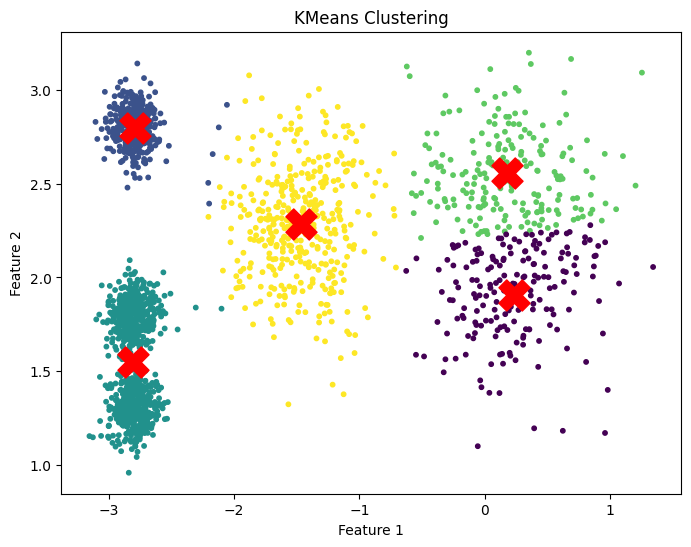

In [ ]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans 

blob_centers = np.array(
[[ 0.2, 2.3],
[-1.5 , 2.3],
[-2.8, 1.8],
[-2.8, 2.8],
[-2.8, 1.3]]) # make_blobs will create clusters around these centers

blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])
X, y = make_blobs(n_samples=2000, centers=blob_centers, cluster_std=blob_std, random_state=7)

kmeans = KMeans(n_clusters=5) # create a KMeans instance with 5 clusters, which is the number of centers we defined for our blobs
y_pred = kmeans.fit_predict(X)
print(y_pred)

# Notera, vi har inte genomfört en klassificering här utan klustring. Vad är skillnaden? 
print(kmeans.labels_)


# ---- Visualization ----
plt.figure(figsize=(8, 6))

# Plot clustered points
plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=10)

# Plot centroids
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c = 'r', marker='X', s=500)

plt.title("KMeans Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

In [8]:
# Transform X to a cluster-distance space.
kmeans.transform(X)

array([[0.11146795, 3.04611916, 1.45402521, 1.54944305, 0.46779778],
       [0.51431557, 3.11541584, 0.99002955, 1.48612753, 0.07122059],
       [3.76340605, 1.32016676, 4.09069201, 2.67154781, 3.81713488],
       ...,
       [1.42865797, 3.04886464, 0.06769209, 1.40795651, 0.92830156],
       [3.23385668, 0.14895409, 3.05913478, 1.71125   , 3.10300136],
       [0.67518173, 2.8625311 , 0.85434589, 1.21678483, 0.22700281]])

### Hur välja antal kluster? 
Vi använder utvärderingsmått! (För regression använde vi t.ex. "RMSE" och för klassificering använde vi t.ex. "confusion matrix".)

* Inertia: Medelkvadratavståndet mellan varje observation och dess närmaste centroid. **Fråga, vad händer per definition när du ökar antalet kluster? Kolla bl.a. på figur 6.10 på s.247.**
* Silhouette coefficient: $SC = \frac{b - a}{\max(a, b)}$
där 𝑎 = Medelvärdet av avståndet till alla andra punkter i samma kluster (intra cluster
distance) och 𝑏 = Medelvärdet av avståndet till alla andra punkter i det kluster som
ligger närmast (nearest cluster distance). **Siluette score är medelvärdet av varje observations SC.**

Siluettkoefficienten är alltid ett tal mellan -1 och +1. Om koefficienten är nära +1
betyder det att datapunkten befinner sig inom sitt eget kluster och har ett långt avstånd till andra kluster. Om koefficienten är nära 0 betyder det att datapunkten ligger nära
en klustergräns. Slutligen, om koefficienten är nära -1 betyder det att datapunkten
potentiellt blivit tilldelad fel kluster. Målet är att silhouette score ska vara så hög som
möjligt, alltså så nära +1 som möjligt.

### Vilken modell nedan väljer du och varför? 

In [7]:
# Calculation of silhouette score and Inertia. 
from sklearn.metrics import silhouette_score 

# Creating two models and computing silhouette scores
kmeans_1 = KMeans(n_clusters=8, random_state = 5).fit(X)
kmeans_2 = KMeans(n_clusters=5, random_state = 5).fit(X)

sc_m1 = silhouette_score(X, kmeans_1.labels_) 
sc_m2 = silhouette_score(X, kmeans_2.labels_)

# Print results
print("Silhouette score for model 1:", sc_m1)
print("Inertia for model 1:", kmeans_1.inertia_)

print("Silhouette score for model 2:", sc_m2)
print("Inertia for model 2:", kmeans_2.inertia_)



Silhouette score for model 1: 0.5592826029686692
Inertia for model 1: 119.56927594528234
Silhouette score for model 2: 0.6353926199764364
Inertia for model 2: 219.41957150830746


### Silhouette diagram, se sid.250-251 i kursboken. 
**Fråga, hur tolkar du diagrammet? Diskutera med bordsgrannen!**
- Vad visar knivarnas höjd?
- Vad visar knivarnas bredd?
- Vad visar de vertikala linjerna? Vill vi generellt sett att knivarna ska passera de vertikala linjerna? 

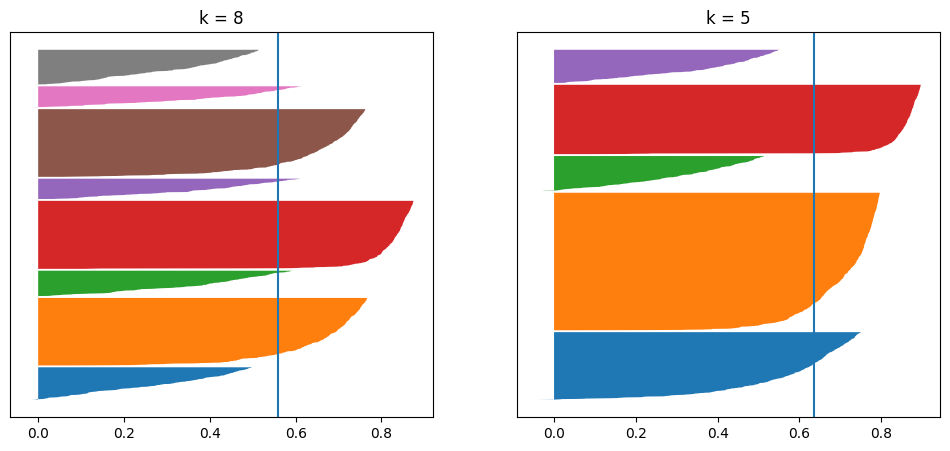

In [8]:
from sklearn.metrics import silhouette_samples

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, kmeans in zip(axes, [kmeans_1, kmeans_2]):
    y_pred = kmeans.labels_
    n_clusters = kmeans.n_clusters
    silhouette_vals = silhouette_samples(X, y_pred)

    y_lower = 10
    for i in range(n_clusters):
        vals = silhouette_vals[y_pred == i]
        vals.sort()
        y_upper = y_lower + len(vals)

        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals)
        y_lower = y_upper + 10

    ax.axvline(x=silhouette_score(X, y_pred))
    ax.set_title(f"k = {n_clusters}")
    ax.set_yticks([])

### Övning - Gå igenom kodexempel 1 på s.252 i kursboken. 